Nonlinear Rao-Style PC-CNN — 2×2 AvgPool r3 Experiment


In [1]:
import copy
import torch
import torch.nn.functional as F

from collections import defaultdict
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from archive.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from src.pc_supervised_rao_nonlinear_avgpool_v1 import HierarchicalPCCNN


In [2]:
SEED = 42
BATCH_SIZE = 16
IMAGE_SIZE = 64

NUM_CLASSES = 20
TRAIN_IMAGES_PER_CLASS = 200
VAL_IMAGES_PER_CLASS = 50
TEST_IMAGES_PER_CLASS = 50

PC_EPOCHS = 5
INFERENCE_STEPS = 50
SUPERVISED_NUDGE_STEPS = 10

SIGMA_CLASS_SQ = 0.5 #1.0
CLASS_LEARNING_RATE = 0.01
CLASS_WEIGHT_DECAY = 0.001


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

print("Device:", device)


Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(TinyImageNetLoader(seed=SEED), image_size=IMAGE_SIZE).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]
selected_classes = list(range(NUM_CLASSES))

print("Full training dataset:", len(train_dataset))
print("Full held-out dataset:", len(test_dataset))


Full training dataset: 99953
Full held-out dataset: 9993


In [5]:
class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)
    if label in selected_classes:
        class_indices[label].append(i)

split_generator = torch.Generator().manual_seed(SEED)
train_indices = []
val_indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]
    required_images = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS
    if len(available_indices) < required_images:
        raise ValueError(
            f"Class {class_id} has only {len(available_indices)} images, but {required_images} are required.")
    permutation = torch.randperm(len(available_indices), generator=split_generator)
    train_indices.extend([available_indices[i] for i in permutation[:TRAIN_IMAGES_PER_CLASS].tolist()])
    val_indices.extend([available_indices[i] for i in
                        permutation[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS].tolist()])

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

assert len(set(train_indices).intersection(set(val_indices))) == 0
assert len(train_subset) == NUM_CLASSES * TRAIN_IMAGES_PER_CLASS
assert len(val_subset) == NUM_CLASSES * VAL_IMAGES_PER_CLASS

train_loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=train_loader_generator)
train_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

K2_DECAYS_PER_EPOCH = 1.5
K2_DECAY_INTERVAL = max(1, round(len(train_subset) / K2_DECAYS_PER_EPOCH))

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("k2 decays per epoch:", K2_DECAYS_PER_EPOCH)
print("k2 decay interval:", K2_DECAY_INTERVAL)


Training images: 4000
Validation images: 1000
Training batches: 250
Validation batches: 63
k2 decays per epoch: 1.5
k2 decay interval: 2667


In [6]:
test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)
    if label in selected_classes:
        test_class_indices[label].append(i)

test_generator = torch.Generator().manual_seed(SEED)
test_indices = []

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]
    if len(available_indices) < TEST_IMAGES_PER_CLASS:
        raise ValueError(
            f"Test class {class_id} has only {len(available_indices)} images, but {TEST_IMAGES_PER_CLASS} were requested.")
    permutation = torch.randperm(len(available_indices), generator=test_generator)
    test_indices.extend([available_indices[i] for i in permutation[:TEST_IMAGES_PER_CLASS].tolist()])

test_subset = Subset(test_dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Test images:", len(test_subset))
print("Test batches:", len(test_loader))


Test images: 1000
Test batches: 63


In [7]:
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

model = HierarchicalPCCNN(
    num_classes=NUM_CLASSES, input_size=IMAGE_SIZE, inference_steps=INFERENCE_STEPS,
    supervised_nudge_steps=SUPERVISED_NUDGE_STEPS, convergence_tolerance=1e-5,
    sigma_class_sq=SIGMA_CLASS_SQ, class_learning_rate=CLASS_LEARNING_RATE,
    lambda_class=CLASS_WEIGHT_DECAY, k2_decay_interval=K2_DECAY_INTERVAL).to(device)

initial_u1 = model.level1["conv"].weight.detach().cpu().clone()
initial_u2 = model.level2["conv"].weight.detach().cpu().clone()
initial_u3 = model.level3["conv"].weight.detach().cpu().clone()
initial_wc = model.classifier.weight.detach().cpu().clone()
initial_bc = model.classifier.bias.detach().cpu().clone()

print("class_learning_rate:", model.class_learning_rate)
print("lambda_class:", model.lambda_class)
print("k2 decay interval:", model.k2_decay_interval)
print("Total unique parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("Autograd-enabled parameters:",
      sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))
print("r3 size:", (256, model.r3_size, model.r3_size))
print("pooled classifier size:", (256, model.classifier_spatial_size, model.classifier_spatial_size))
print("classifier feature dim:", model.classifier_feature_dim)
print("classifier weight shape:", tuple(model.classifier.weight.shape))


class_learning_rate: 0.01
lambda_class: 0.001
k2 decay interval: 2667
Total unique parameters: 414580
Autograd-enabled parameters: 0
r3 size: (256, 8, 8)
pooled classifier size: (256, 4, 4)
classifier feature dim: 4096
classifier weight shape: (20, 4096)


In [8]:
@torch.no_grad()
def evaluate_model(model: HierarchicalPCCNN, data_loader, device, name=""):
    total_loss = 0.0
    total_correct = 0
    total_images = 0
    total_steps = 0
    total_converged = 0
    model.eval()

    for images, labels in tqdm(data_loader, desc=f"Evaluation Nonlinear Rao PC-CNN - {name}"):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)
        result = model.classify_batch(images)
        probabilities = result["probabilities"]
        predictions = result["predictions"]
        true_probabilities = probabilities[torch.arange(labels.shape[0], device=labels.device), labels]
        loss = -torch.log(true_probabilities + 1e-8).mean().item()
        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]
        total_steps += sum(result["inference_steps"])
        total_converged += sum(int(value) for value in result["converged"])

    return total_loss / total_images, 100.0 * total_correct / total_images, total_steps / total_images, 100.0 * total_converged / total_images


In [9]:
import matplotlib.pyplot as plt
import math

@torch.no_grad()
def show_all_latent_feature_maps(model: HierarchicalPCCNN, dataset, device, image_index=0, columns=16):
    image, label = dataset[image_index]
    model.eval()
    result = model.reconstruct(image.to(device))

    print("True Class:", int(label))
    print("Predicted Class:", result["predicted_class"])
    print("r1 shape:", result["r1"].shape)
    print("r2 shape:", result["r2"].shape)
    print("r3 shape:", result["r3"].shape)

    def to_display(image):
        image = image.detach().cpu().clamp(0, 1)
        return image.permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(to_display(image))
    axes[0].set_title(f"Original | Class {int(label)}")
    axes[0].axis("off")
    axes[1].imshow(to_display(result["reconstruction"]))
    axes[1].set_title(f"Reconstructed | Predicted {result['predicted_class']}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    def plot_all_channels(state, layer_name, columns=16):
        state = state.detach().cpu()
        if state.ndim == 4: state = state.squeeze(0)

        num_channels = state.shape[0]
        rows = math.ceil(num_channels / columns)
        fig, axes = plt.subplots(rows, columns, figsize=(columns * 1.5, rows * 1.5))
        axes = axes.flatten()

        for channel in range(num_channels):
            feature_map = state[channel]
            min_value, max_value = feature_map.min(), feature_map.max()
            display_map = (feature_map - min_value) / (max_value - min_value + 1e-8)
            axes[channel].imshow(display_map, cmap="viridis")
            axes[channel].set_title(f"{layer_name}-{channel}", fontsize=7)
            axes[channel].axis("off")

        for channel in range(num_channels, len(axes)): axes[channel].axis("off")

        plt.suptitle(f"{layer_name} — All {num_channels} Feature Maps", fontsize=18)
        plt.tight_layout()
        plt.show()

    plot_all_channels(result["r1"], "r1", columns)
    plot_all_channels(result["r2"], "r2", columns)
    plot_all_channels(result["r3"], "r3", columns)

True Class: 0
Predicted Class: 12
r1 shape: torch.Size([32, 32, 32])
r2 shape: torch.Size([128, 16, 16])
r3 shape: torch.Size([256, 8, 8])


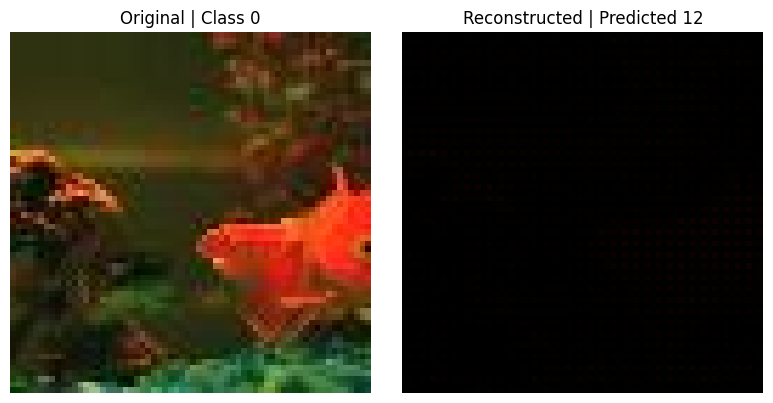

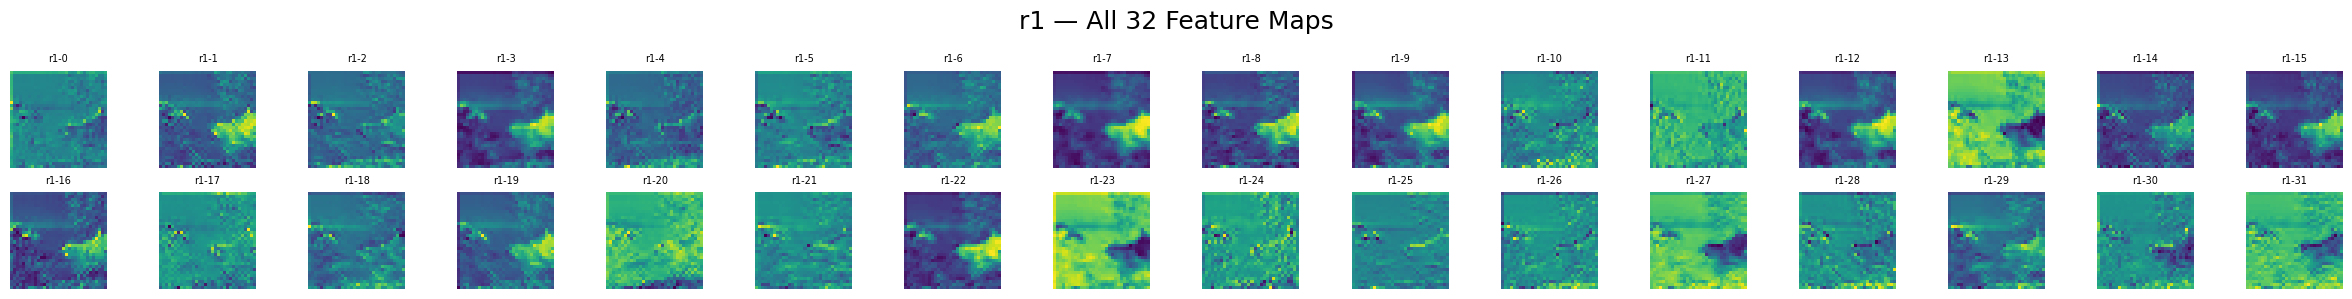

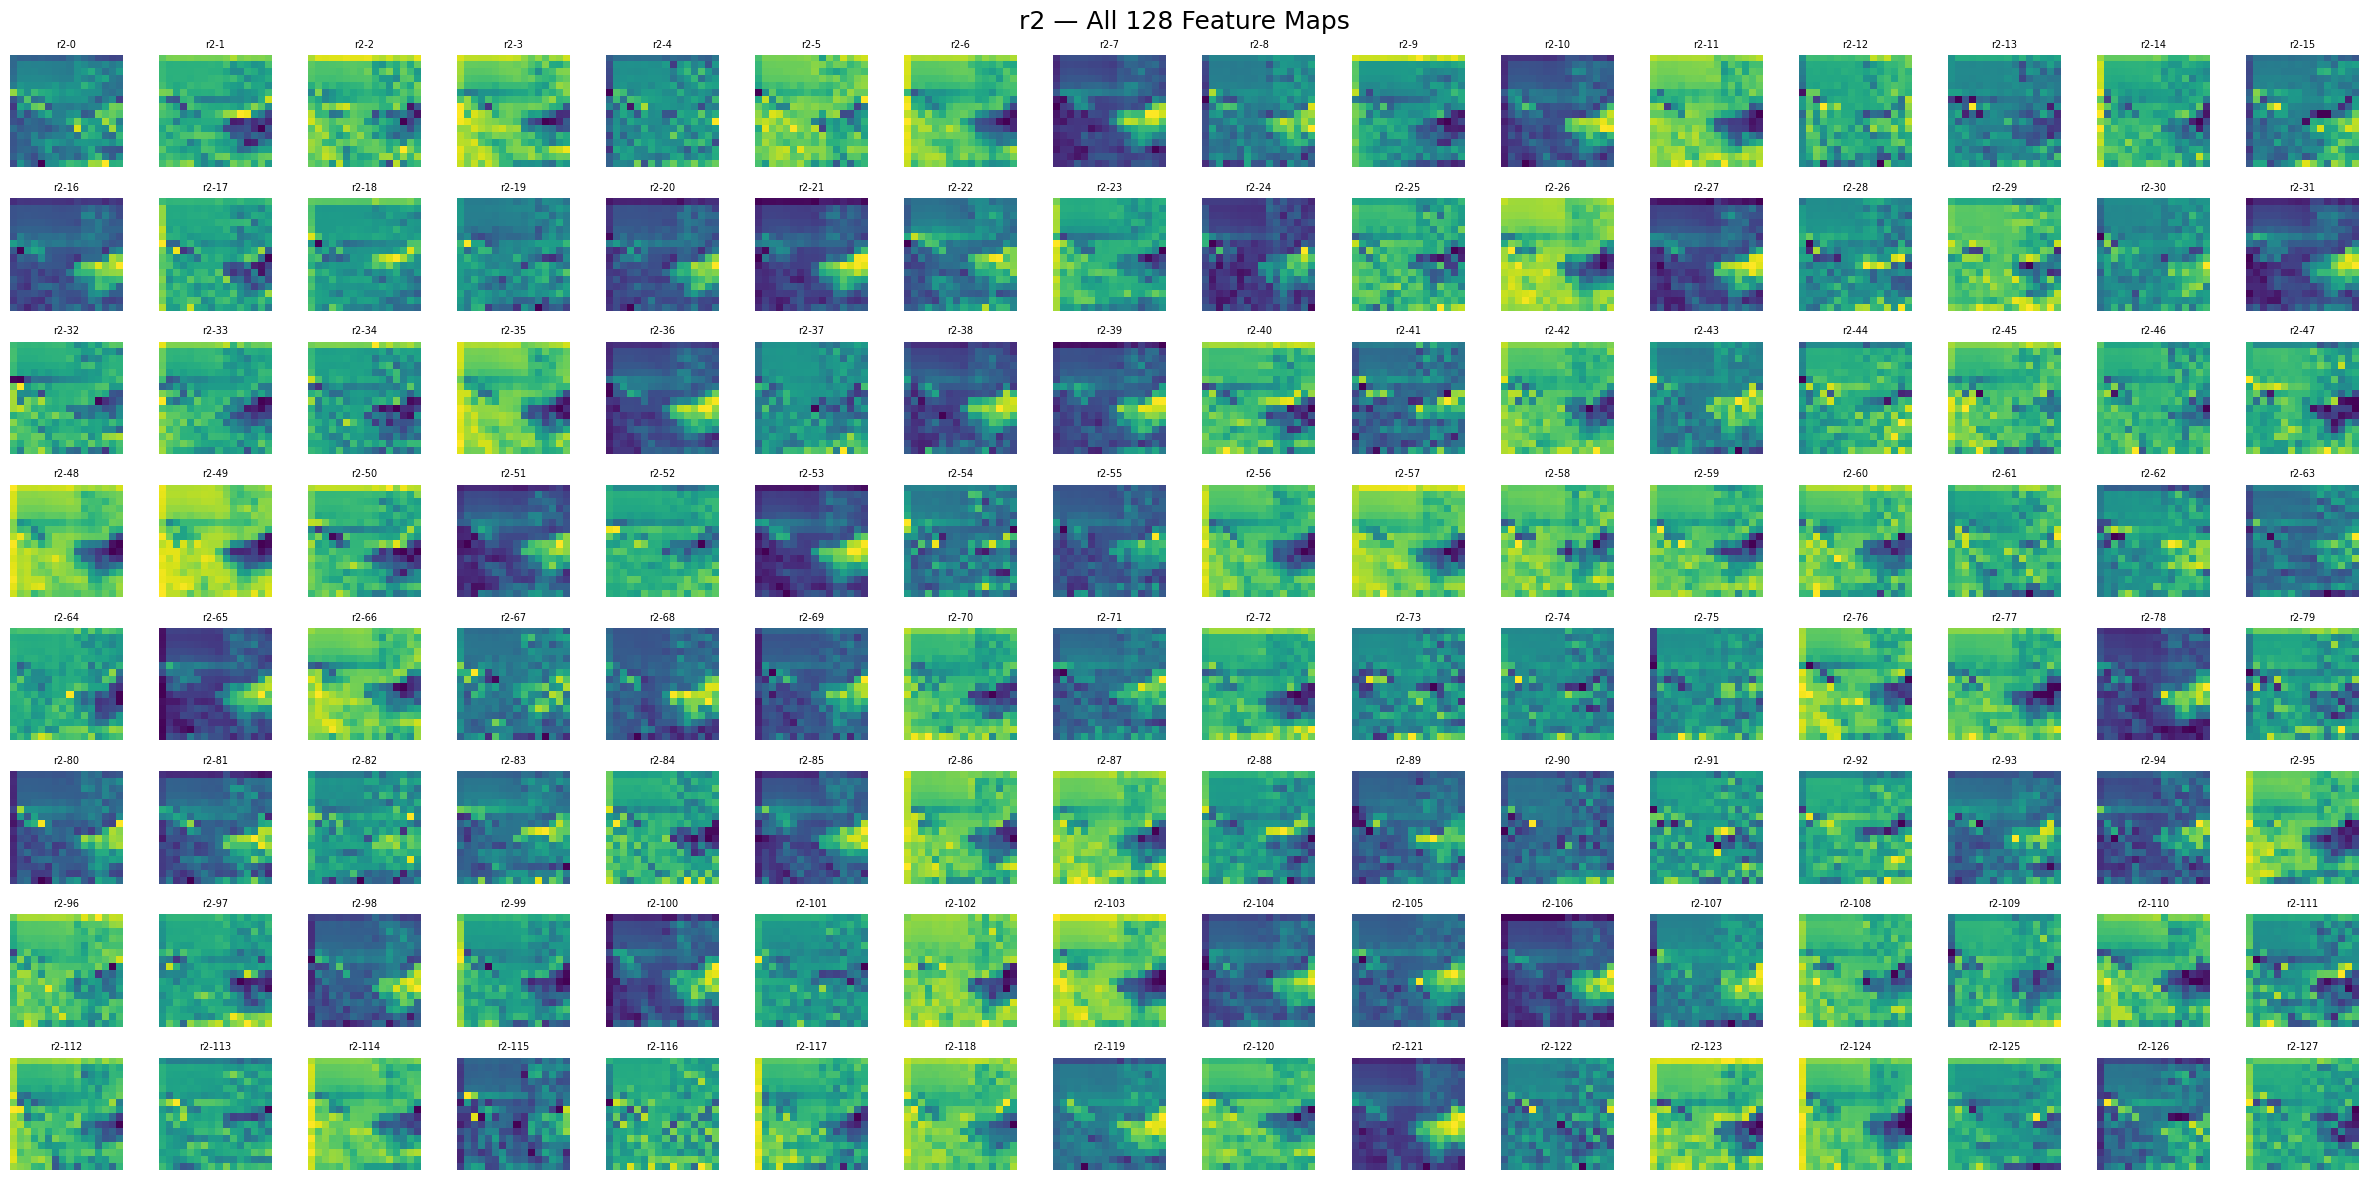

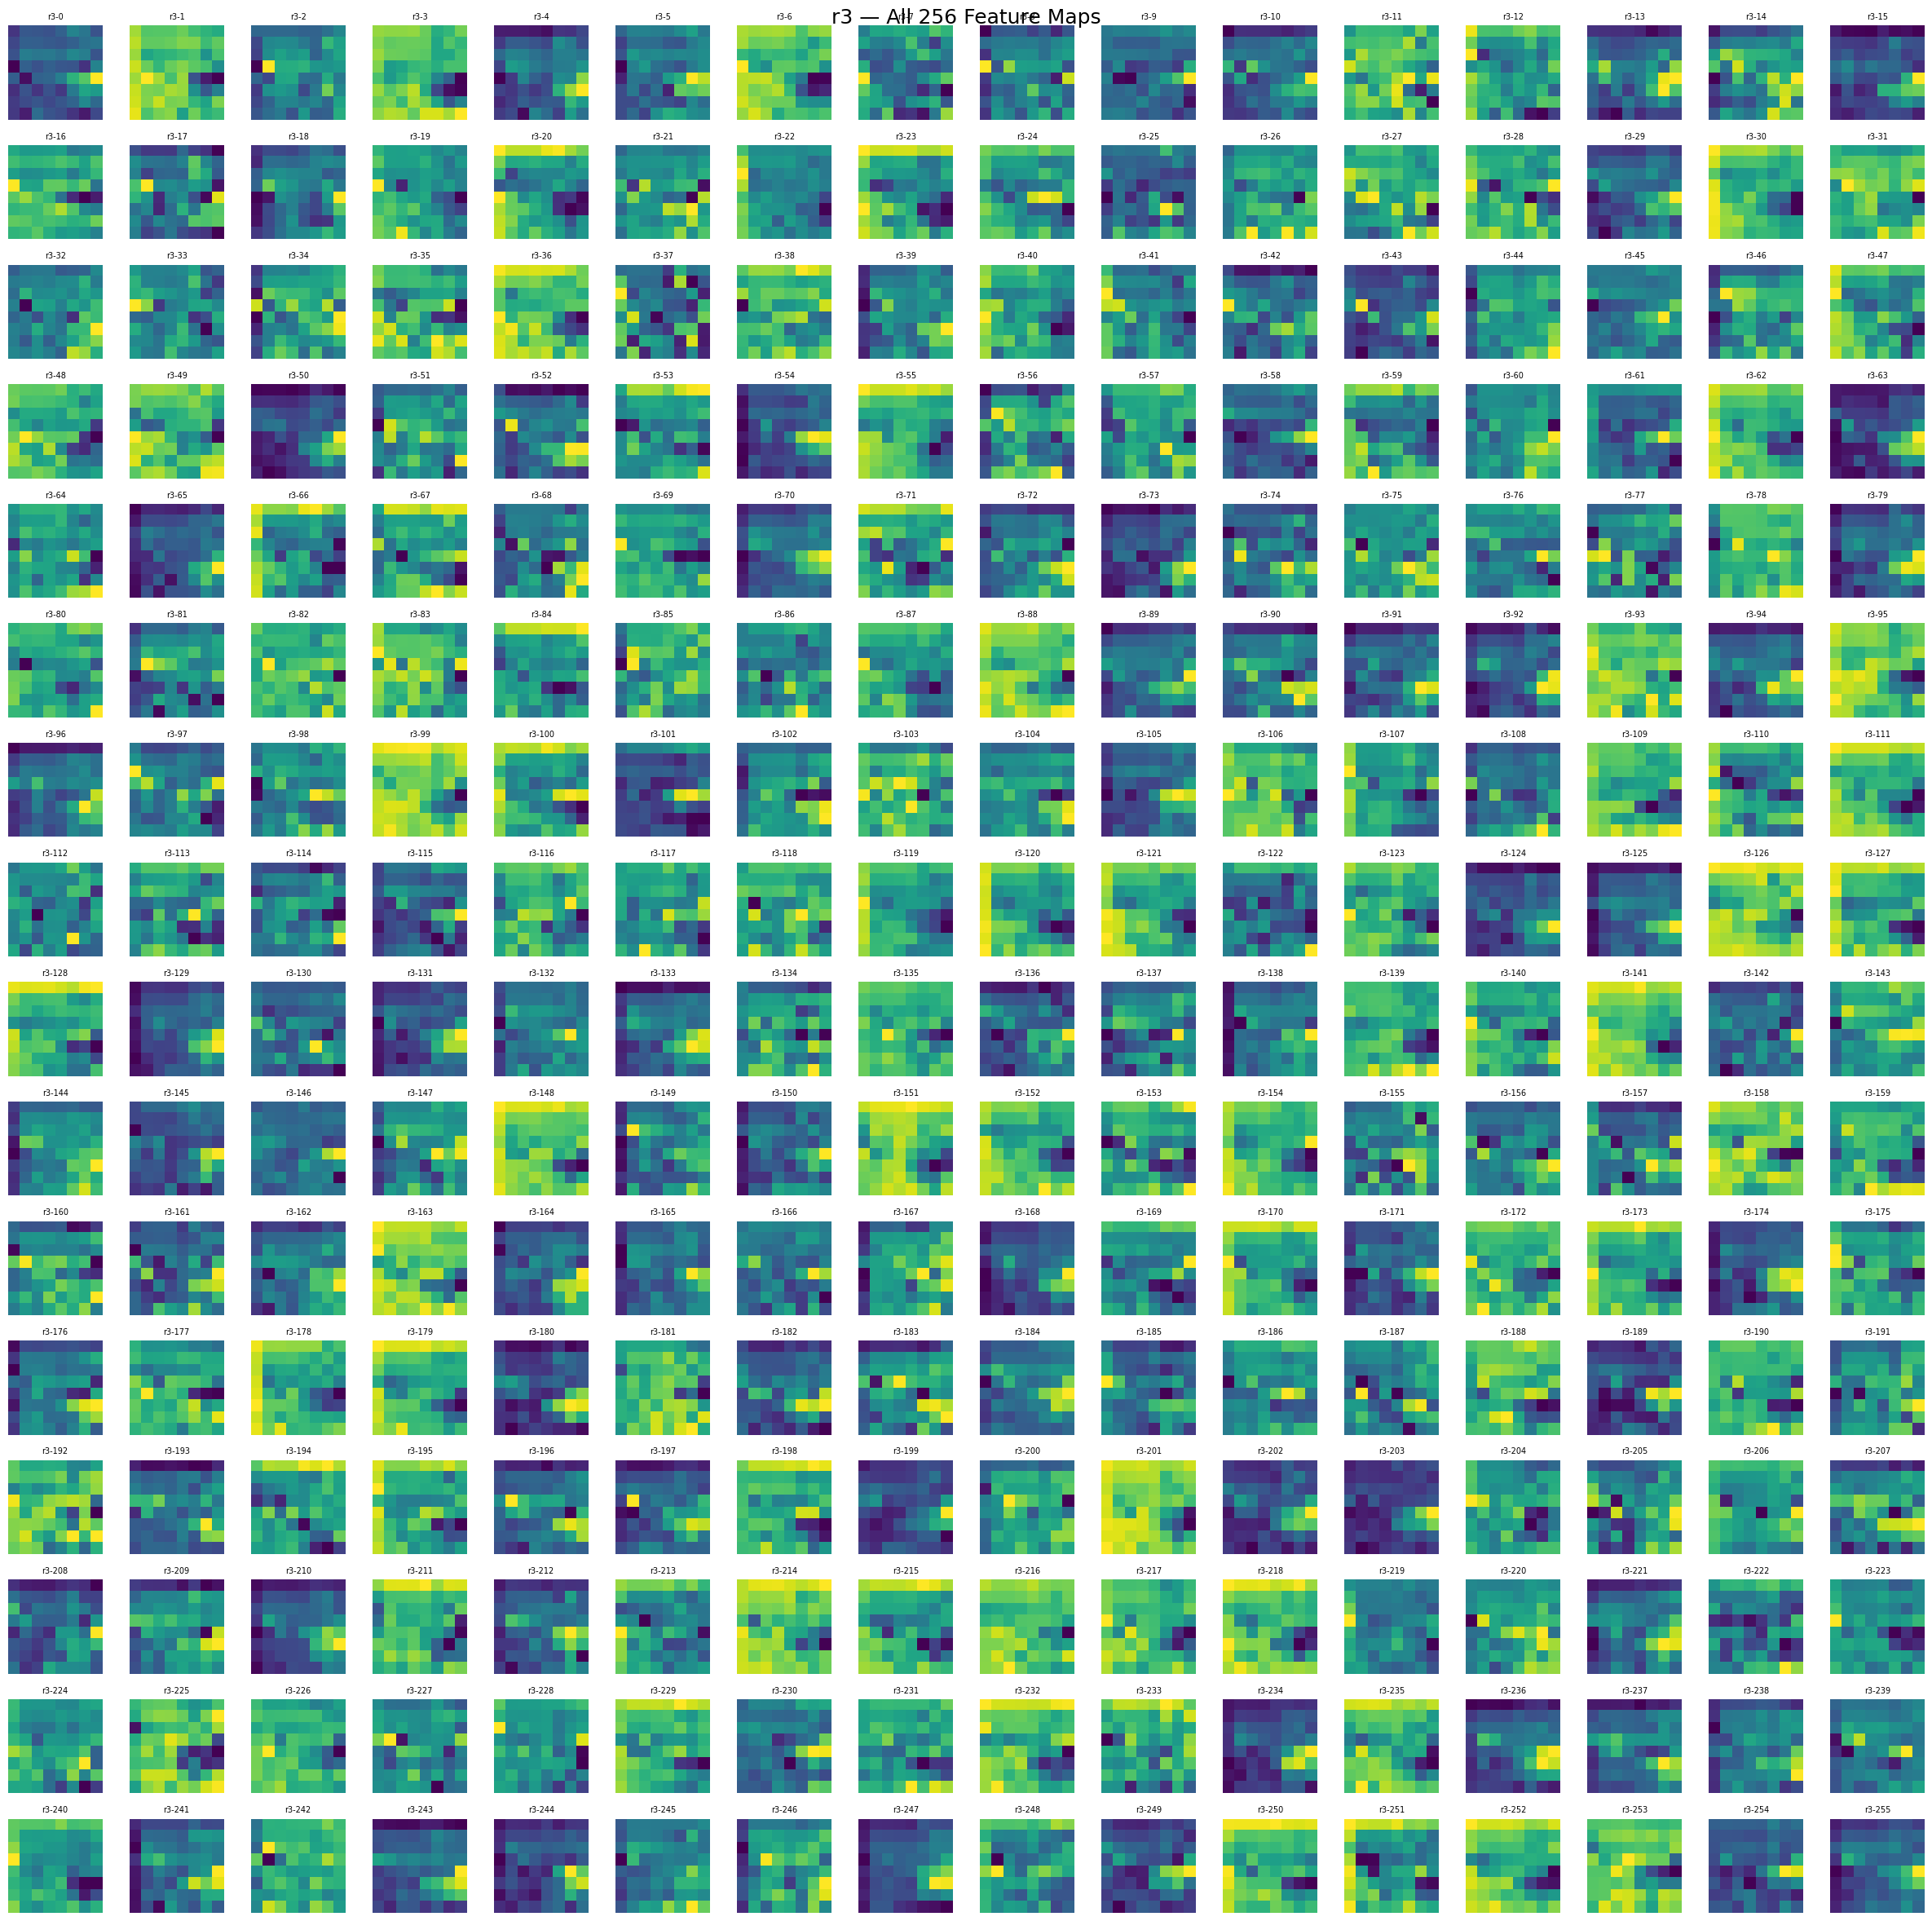

In [10]:
show_all_latent_feature_maps(model, val_subset, device, image_index=3, columns=16)

In [11]:
history = []
best_val_accuracy = -1.0
best_val_loss = float("inf")
best_epoch = None
best_model_state = None
best_k2 = None
best_training_input_count = None

for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_error_2 = 0.0
    total_class_error = 0.0
    total_nudged_error_0 = 0.0
    total_nudged_error_1 = 0.0
    total_nudged_error_2 = 0.0
    total_class_loss = 0.0
    total_images = 0
    model.train()

    for images, labels in tqdm(train_loader, desc=f"Nonlinear Rao PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}"):
        for image, label in zip(images, labels):
            image = image.to(device)
            label = label.to(device=device, dtype=torch.long)
            result = model(image, label)
            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_error_2 += result["error_2"]
            total_class_error += result["class_error"]
            total_nudged_error_0 += result["nudged_error_0"]
            total_nudged_error_1 += result["nudged_error_1"]
            total_nudged_error_2 += result["nudged_error_2"]
            total_class_loss += result["class_loss"]
            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images
    mean_error_2 = total_error_2 / total_images
    mean_class_error = total_class_error / total_images
    mean_nudged_error_0 = total_nudged_error_0 / total_images
    mean_nudged_error_1 = total_nudged_error_1 / total_images
    mean_nudged_error_2 = total_nudged_error_2 / total_images
    mean_class_loss = total_class_loss / total_images

    train_loss, train_accuracy, train_steps, train_convergence = evaluate_model(model, train_eval_loader, device, "Train")
    val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, "Validation")

    history.append({
        "epoch": epoch + 1, "train_loss": train_loss, "train_accuracy": train_accuracy,
        "val_loss": val_loss, "val_accuracy": val_accuracy, "k2": model.k2
    })

    is_better = val_loss < best_val_loss
    if val_loss == best_val_loss and val_accuracy > best_val_accuracy:
        is_better = True

    if is_better:
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        best_k2 = model.k2
        best_training_input_count = model.training_input_count

    print(
        f"Epoch {epoch + 1}/{PC_EPOCHS} | e0: {mean_error_0:.6f} | e1: {mean_error_1:.6f} | e2: {mean_error_2:.6f} | Class e: {mean_class_error:.6f} | Nudge e0: {mean_nudged_error_0:.6f} | Nudge e1: {mean_nudged_error_1:.6f} | Nudge e2: {mean_nudged_error_2:.6f}")
    print(
        f"Class Loss: {mean_class_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}% | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | k2: {model.k2:.8f}")
    print(f"Train Convergence: {train_convergence:.2f}% | Val Convergence: {val_convergence:.2f}%")


Nonlinear Rao PC-CNN Epoch 1/5:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Train:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/5 | e0: 0.089911 | e1: 0.039185 | e2: 0.024424 | Class e: 0.214614 | Nudge e0: 0.073517 | Nudge e1: 0.046803 | Nudge e2: 0.035115
Class Loss: 2.8657 | Train Acc: 18.50% | Val Acc: 17.10% | Train Loss: 2.7544 | Val Loss: 2.7829 | k2: 0.98522167
Train Convergence: 0.00% | Val Convergence: 0.00%


Nonlinear Rao PC-CNN Epoch 2/5:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 4/5 | e0: 0.058421 | e1: 0.032908 | e2: 0.026622 | Class e: 0.206600 | Nudge e0: 0.032770 | Nudge e1: 0.030538 | Nudge e2: 0.037547
Class Loss: 2.5841 | Train Acc: 26.25% | Val Acc: 22.20% | Train Loss: 2.5494 | Val Loss: 2.6372 | k2: 0.92826033
Train Convergence: 0.00% | Val Convergence: 0.00%


Nonlinear Rao PC-CNN Epoch 5/5:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Train:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluation Nonlinear Rao PC-CNN - Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/5 | e0: 0.058464 | e1: 0.032424 | e2: 0.026370 | Class e: 0.205622 | Nudge e0: 0.032570 | Nudge e1: 0.029428 | Nudge e2: 0.035828
Class Loss: 2.5532 | Train Acc: 24.10% | Val Acc: 18.80% | Train Loss: 2.5239 | Val Loss: 2.6281 | k2: 0.90102679
Train Convergence: 0.00% | Val Convergence: 0.00%


In [12]:
print("AFTER TRAINING")
print("Inference Steps: ", model.inference_steps)
print("training_input_count:", model.training_input_count)
print("k2:", model.k2)
print("U1 norm:", model.level1["conv"].weight.norm().item())
print("U2 norm:", model.level2["conv"].weight.norm().item())
print("U3 norm:", model.level3["conv"].weight.norm().item())
print("Wc norm:", model.classifier.weight.norm().item())
print("bc norm:", model.classifier.bias.norm().item())
print("U1 change:", torch.norm(model.level1["conv"].weight.detach().cpu() - initial_u1).item())
print("U2 change:", torch.norm(model.level2["conv"].weight.detach().cpu() - initial_u2).item())
print("U3 change:", torch.norm(model.level3["conv"].weight.detach().cpu() - initial_u3).item())
print("Wc change:", torch.norm(model.classifier.weight.detach().cpu() - initial_wc).item())
print("bc change:", torch.norm(model.classifier.bias.detach().cpu() - initial_bc).item())


AFTER TRAINING
Inference Steps:  50
training_input_count: 20000
k2: 0.9010267906580017
U1 norm: 1.5776997804641724
U2 norm: 3.771009922027588
U3 norm: 5.780747413635254
Wc norm: 7.965093612670898
bc norm: 2.1084043979644775
U1 change: 1.4692394733428955
U2 change: 3.7540805339813232
U3 change: 6.890232563018799
Wc change: 7.6243815422058105
bc change: 2.1084043979644775


In [ ]:
if best_model_state is None:
    raise RuntimeError("No model checkpoint was saved.")

model.load_state_dict(best_model_state)
model.k2 = best_k2
model.training_input_count = best_training_input_count
model.eval()

print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")
print("Best validation loss:", f"{best_val_loss:.4f}")
print("Best Wc norm:", model.classifier.weight.norm().item())
print("Best k2:", model.k2)


True Class: 0
Predicted Class: 0
r1 shape: torch.Size([32, 32, 32])
r2 shape: torch.Size([128, 16, 16])
r3 shape: torch.Size([256, 8, 8])


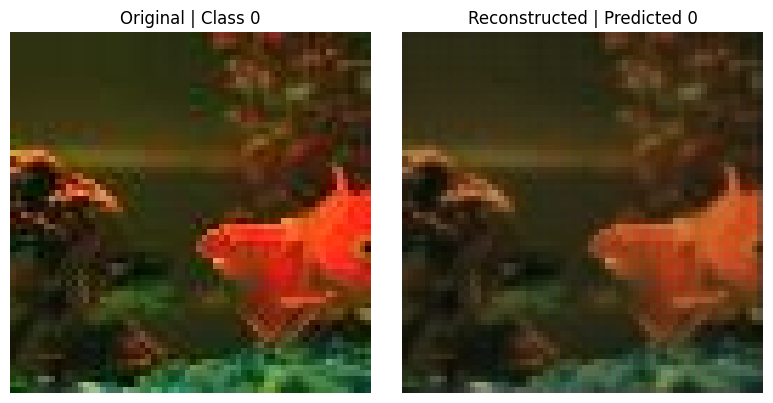

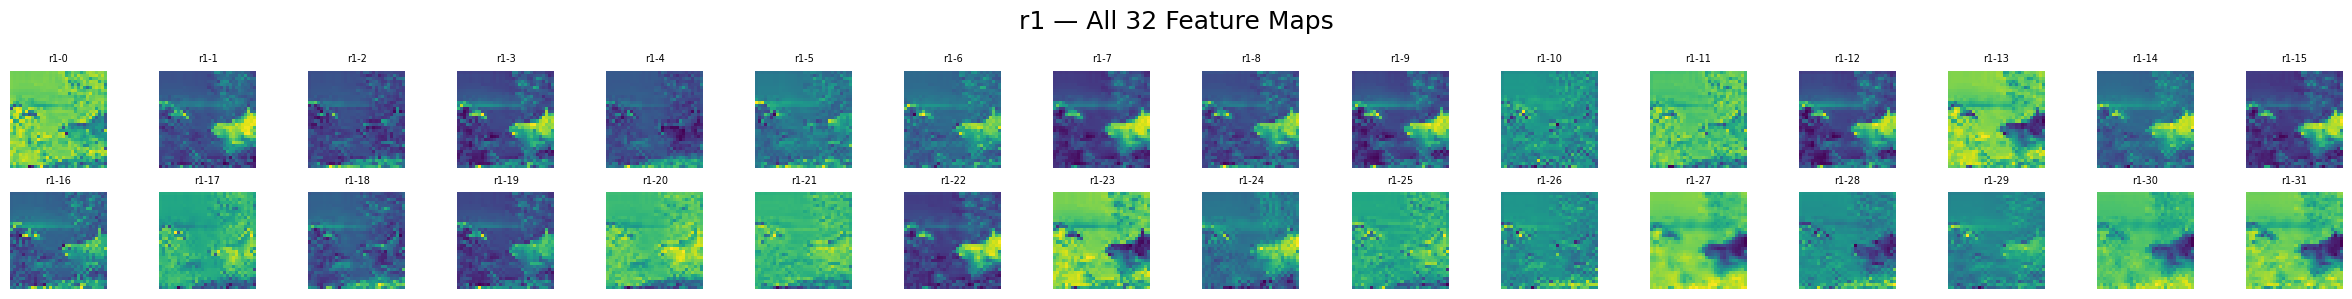

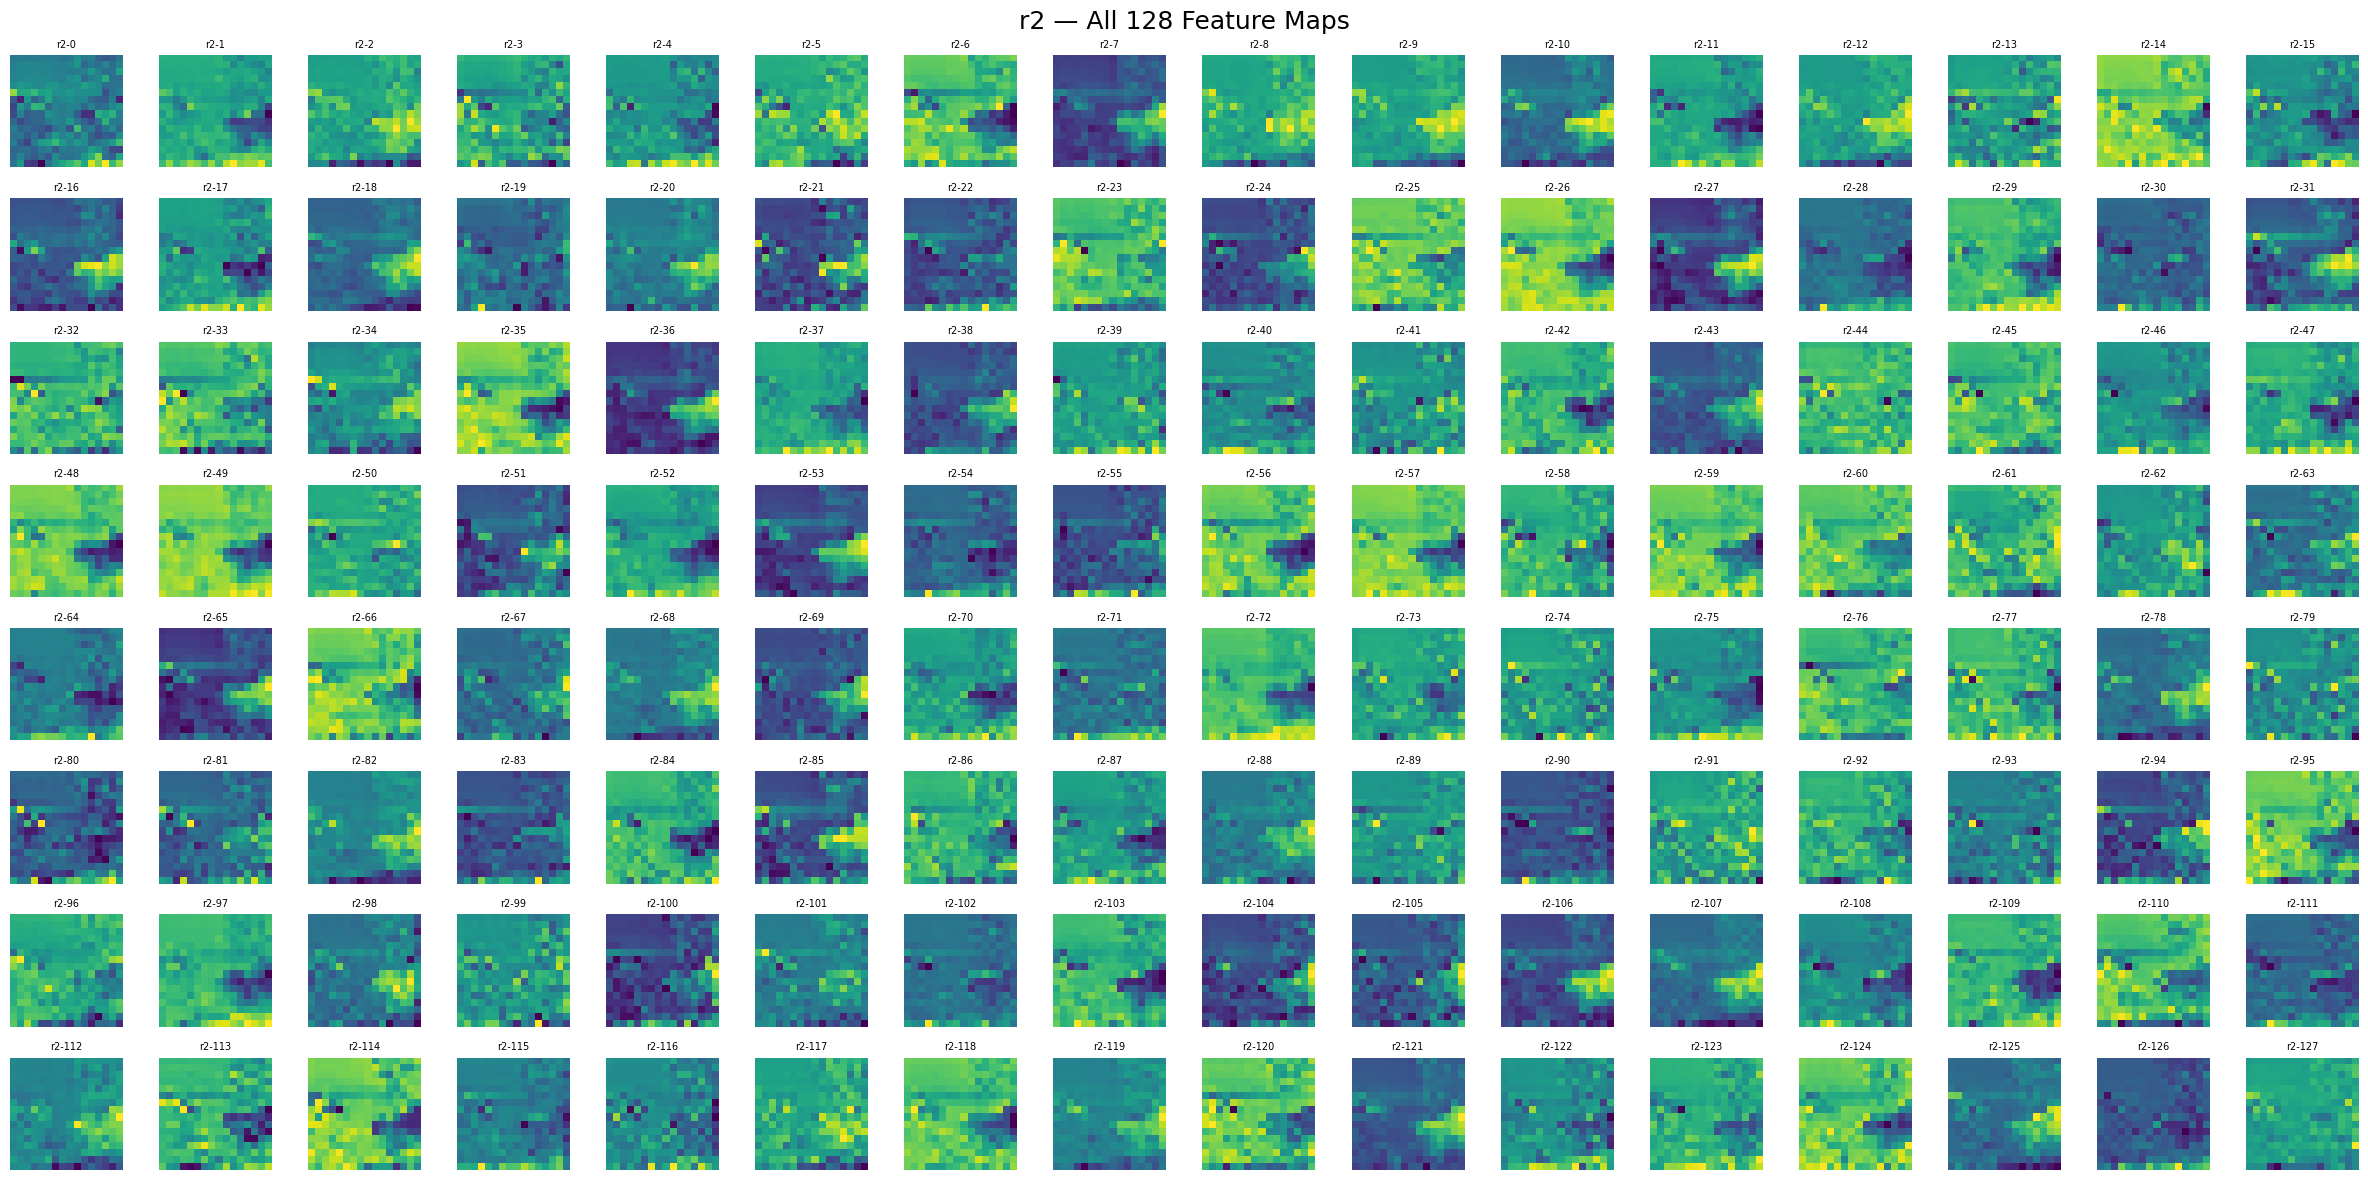

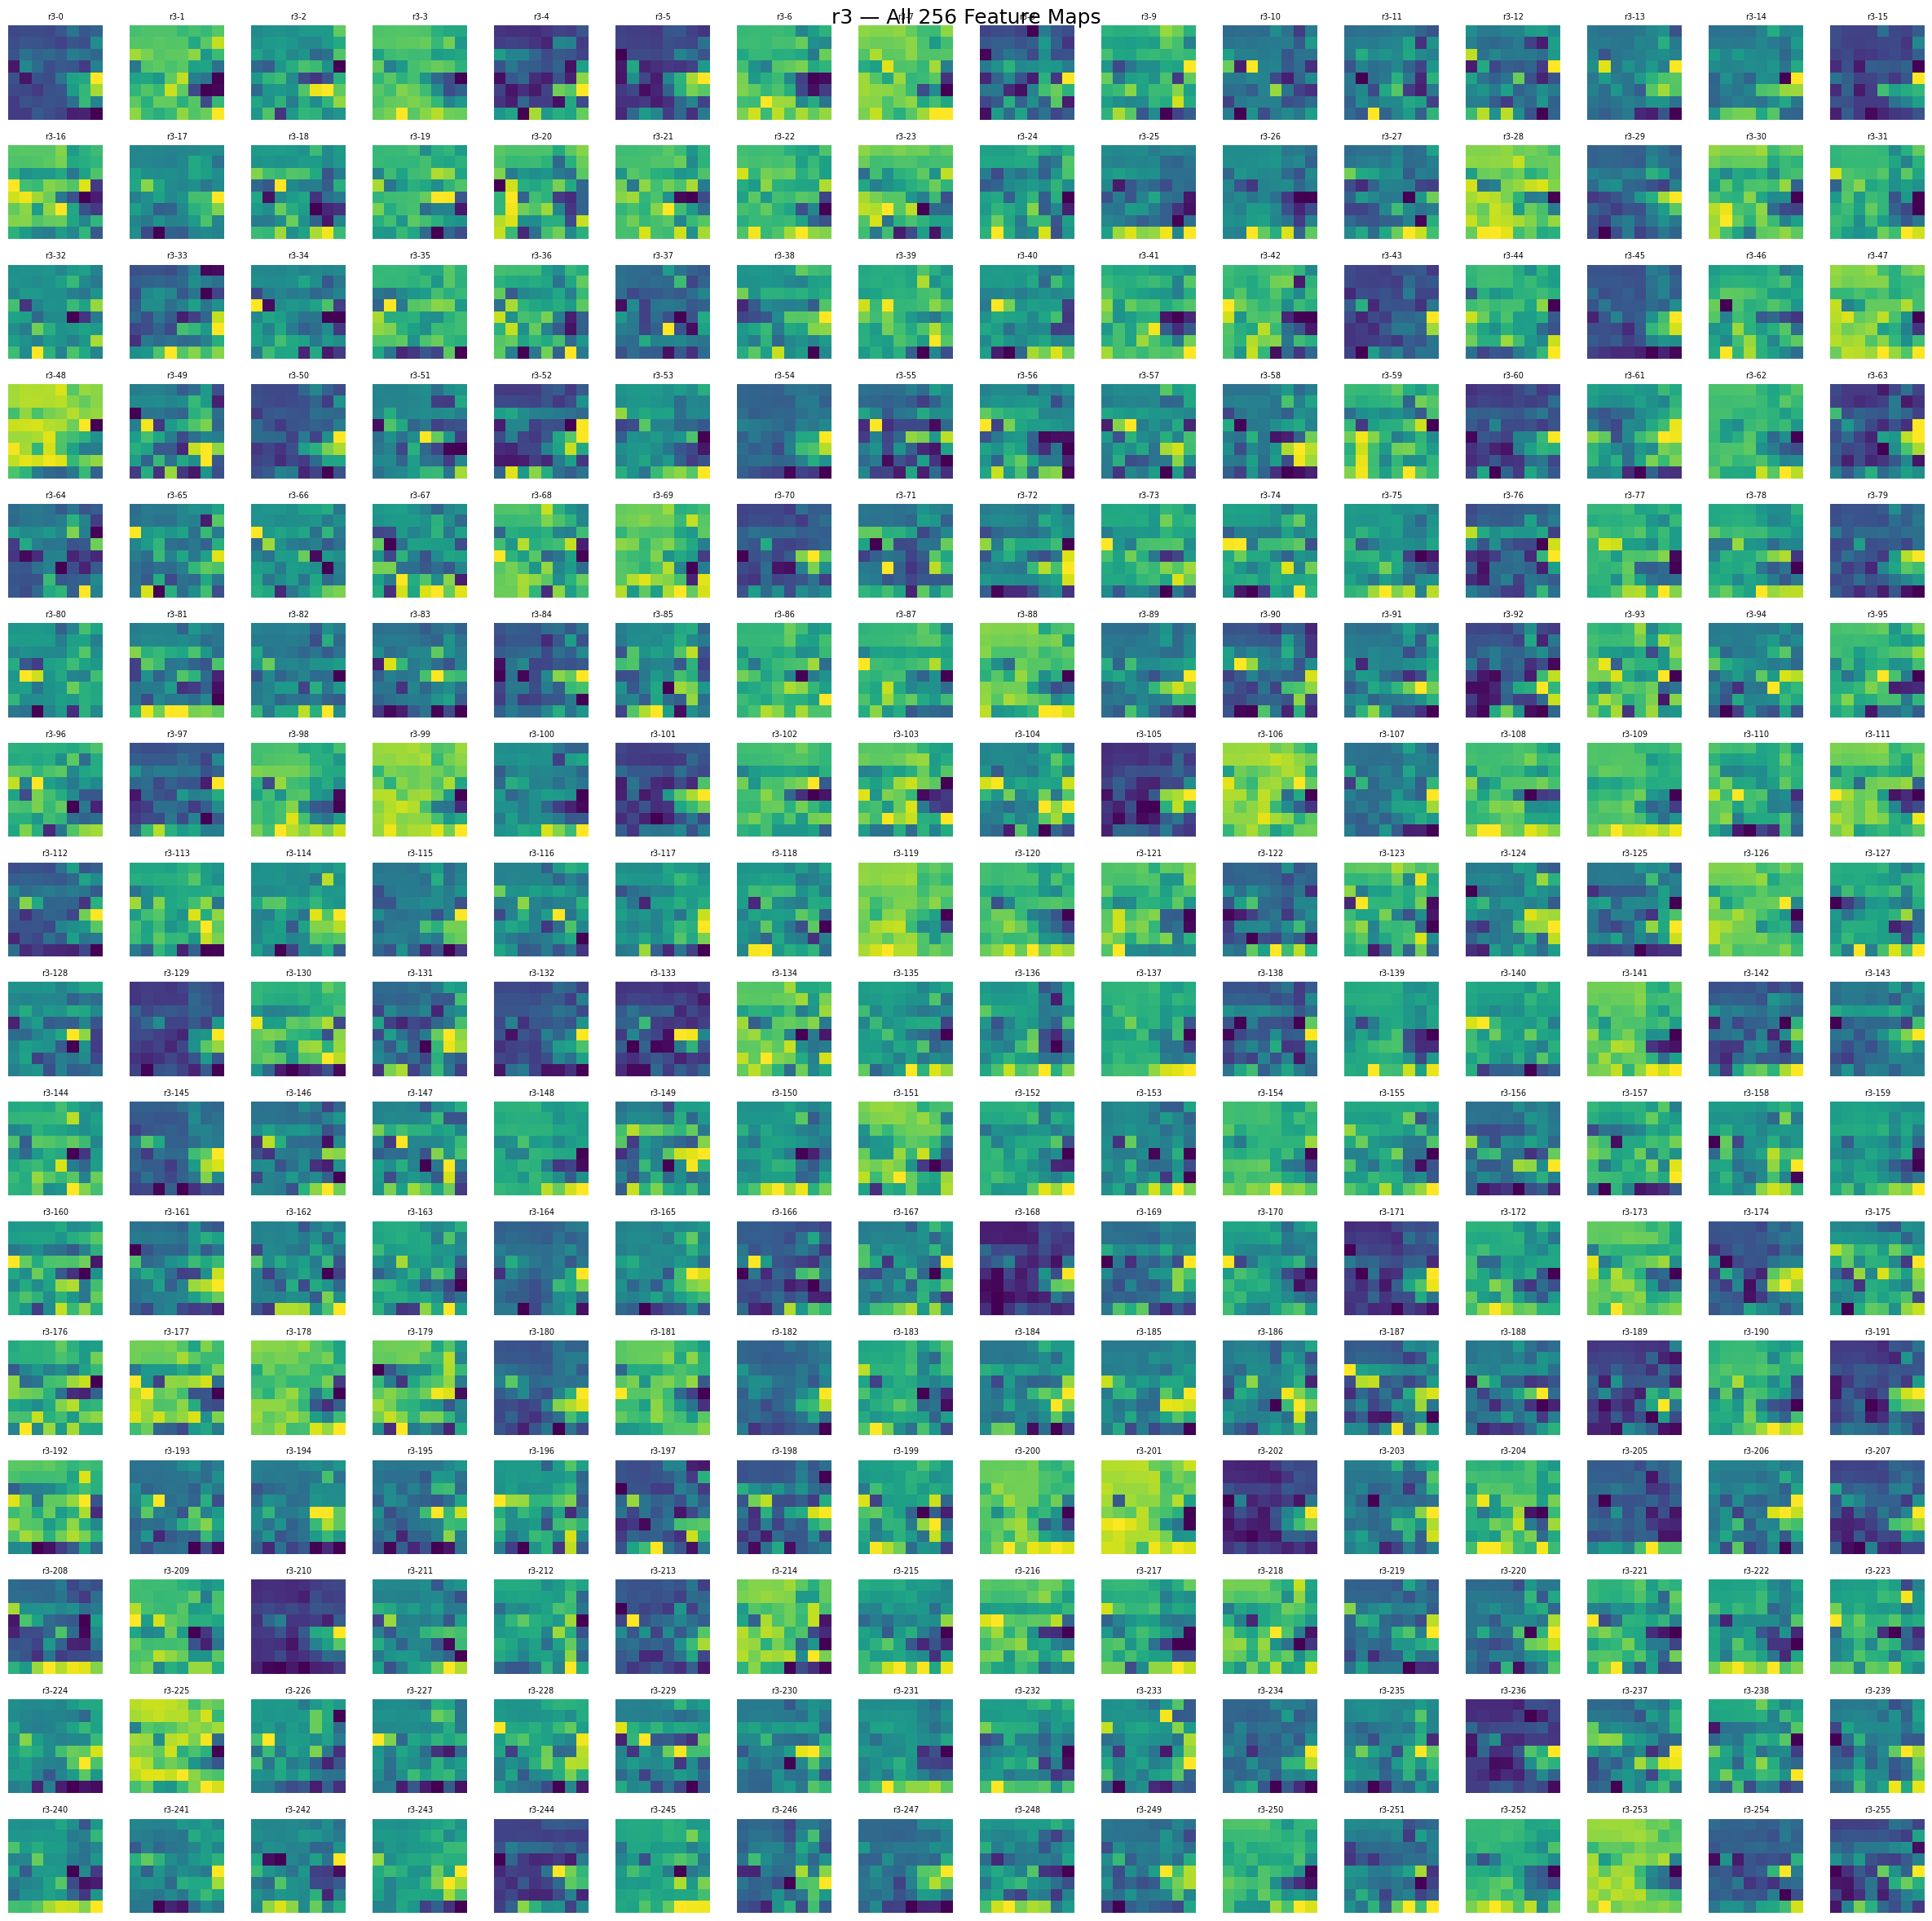

In [13]:
show_all_latent_feature_maps(model, val_subset, device, image_index=3, columns=16)

In [ ]:
original_inference_steps = model.inference_steps

model.inference_steps = 20
val_loss_20, val_accuracy_20, _, val_convergence_20 = evaluate_model(model, val_loader, device, "Validation 20 Steps")

model.inference_steps = 50
val_loss_50, val_accuracy_50, _, val_convergence_50 = evaluate_model(model, val_loader, device, "Validation 50 Steps")

model.inference_steps = 100
val_loss_100, val_accuracy_100, _, val_convergence_100 = evaluate_model(model, val_loader, device, "Validation 100 Steps")

model.inference_steps = original_inference_steps

print("20 steps :", f"Accuracy={val_accuracy_20:.2f}% | Loss={val_loss_20:.4f} | Convergence={val_convergence_20:.2f}%")
print("50 steps :", f"Accuracy={val_accuracy_50:.2f}% | Loss={val_loss_50:.4f} | Convergence={val_convergence_50:.2f}%")
print("100 steps:", f"Accuracy={val_accuracy_100:.2f}% | Loss={val_loss_100:.4f} | Convergence={val_convergence_100:.2f}%")


In [14]:
@torch.no_grad()
def confidence_diagnostics(model, data_loader, device, name):
    model.eval()
    correct_confidences = []
    wrong_confidences = []
    true_class_probabilities = []

    for images, labels in tqdm(data_loader):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)
        result = model.classify_batch(images)
        probabilities = result["probabilities"]
        predictions = result["predictions"]
        confidences = probabilities.max(dim=1).values
        true_probs = probabilities[torch.arange(labels.shape[0], device=device), labels]
        correct_mask = predictions == labels
        wrong_mask = predictions != labels
        correct_confidences.extend(confidences[correct_mask].cpu().tolist())
        wrong_confidences.extend(confidences[wrong_mask].cpu().tolist())
        true_class_probabilities.extend(true_probs.cpu().tolist())

    print(name)
    print("Mean true-class probability:", sum(true_class_probabilities) / len(true_class_probabilities))
    print("Mean confidence on correct predictions:",
          sum(correct_confidences) / len(correct_confidences) if correct_confidences else 0.0)
    print("Mean confidence on wrong predictions:",
          sum(wrong_confidences) / len(wrong_confidences) if wrong_confidences else 0.0)


confidence_diagnostics(model, train_eval_loader, device, "TRAIN")
confidence_diagnostics(model, val_loader, device, "VALIDATION")


  0%|          | 0/250 [00:00<?, ?it/s]

TRAIN
Mean true-class probability: 0.11838053845928516
Mean confidence on correct predictions: 0.28008334808577146
Mean confidence on wrong predictions: 0.14469512193972964


  0%|          | 0/63 [00:00<?, ?it/s]

VALIDATION
Mean true-class probability: 0.10746252985543106
Mean confidence on correct predictions: 0.29870357839985096
Mean confidence on wrong predictions: 0.1425487630968464


In [15]:
print(model.inference_steps)

50


In [16]:
@torch.no_grad()
def collect_class_features(model, data_loader, device, num_classes):
    features_by_class = [[] for _ in range(num_classes)]
    model.eval()

    for images, labels in tqdm(data_loader, desc="Collecting POOLED FREE r3 Features"):
        for image, label in zip(images, labels):
            image = image.to(device)
            label = int(label)
            _, _, r3, _, _ = model.infer(image)
            features_by_class[label].append(model.class_features(r3).squeeze(0).detach().cpu())

    return [torch.stack(features) for features in features_by_class]


train_features_by_class = collect_class_features(model, train_eval_loader, device, NUM_CLASSES)
val_features_by_class = collect_class_features(model, val_loader, device, NUM_CLASSES)


In [17]:
print(train_features_by_class)
print(val_features_by_class)

[tensor([[ 0.0248,  0.0135,  0.0010,  ...,  0.0041,  0.0014,  0.0499],
        [ 0.0173,  0.0355,  0.0242,  ...,  0.0835,  0.0869,  0.0812],
        [ 0.0388, -0.0009,  0.0086,  ...,  0.0195,  0.0450,  0.0289],
        ...,
        [-0.0027, -0.0411,  0.0145,  ...,  0.0968,  0.0940,  0.0946],
        [ 0.0158,  0.0012, -0.0030,  ...,  0.0088,  0.0042,  0.0067],
        [-0.0224,  0.0655,  0.0776,  ...,  0.0979,  0.1197,  0.1444]]), tensor([[ 0.0436,  0.0266,  0.0122,  ...,  0.0009, -0.0069,  0.0336],
        [ 0.0258,  0.0527,  0.0574,  ...,  0.0251,  0.0460,  0.0358],
        [-0.0120,  0.0537,  0.0392,  ...,  0.0693,  0.0245,  0.0332],
        ...,
        [ 0.0019,  0.0266, -0.0095,  ...,  0.0032,  0.0358,  0.0593],
        [ 0.0239,  0.0021,  0.0319,  ..., -0.0093,  0.0518,  0.0635],
        [ 0.0175,  0.0237,  0.0912,  ...,  0.0684,  0.0095,  0.0201]]), tensor([[ 0.0188,  0.0032,  0.0248,  ...,  0.0192,  0.0155,  0.0607],
        [-0.0083,  0.0087, -0.0077,  ...,  0.0303,  0.0196,

In [18]:
@torch.no_grad()
def compare_feature_geometry(train_features_by_class, val_features_by_class):
    train_centroids = torch.stack([features.mean(dim=0) for features in train_features_by_class])
    val_centroids = torch.stack([features.mean(dim=0) for features in val_features_by_class])
    train_spread = torch.tensor(
        [torch.norm(features - train_centroids[class_id], dim=1).mean().item() for class_id, features in
         enumerate(train_features_by_class)])
    val_spread_to_train = torch.tensor(
        [torch.norm(features - train_centroids[class_id], dim=1).mean().item() for class_id, features in
         enumerate(val_features_by_class)])
    centroid_shift = torch.norm(val_centroids - train_centroids, dim=1)
    train_centroid_distances = torch.cdist(train_centroids, train_centroids)
    off_diagonal_mask = ~torch.eye(NUM_CLASSES, dtype=torch.bool)
    inter_class_distances = train_centroid_distances[off_diagonal_mask]
    mean_inter_class_distance = inter_class_distances.mean().item()
    minimum_inter_class_distance = inter_class_distances.min().item()
    mean_train_spread = train_spread.mean().item()
    mean_val_spread = val_spread_to_train.mean().item()
    mean_centroid_shift = centroid_shift.mean().item()
    train_separation_ratio = mean_inter_class_distance / mean_train_spread
    val_separation_ratio = mean_inter_class_distance / mean_val_spread

    def nearest_centroid_accuracy(features_by_class, centroids, metric="euclidean"):
        correct = 0
        total = 0
        normalized_centroids = F.normalize(centroids, dim=1)
        for class_id, features in enumerate(features_by_class):
            predictions = torch.cdist(features, centroids).argmin(dim=1) if metric == "euclidean" else (
                        F.normalize(features, dim=1) @ normalized_centroids.T).argmax(dim=1)
            correct += (predictions == class_id).sum().item()
            total += features.shape[0]
        return 100.0 * correct / total

    train_nc_euclidean = nearest_centroid_accuracy(train_features_by_class, train_centroids, "euclidean")
    val_nc_euclidean = nearest_centroid_accuracy(val_features_by_class, train_centroids, "euclidean")
    train_nc_cosine = nearest_centroid_accuracy(train_features_by_class, train_centroids, "cosine")
    val_nc_cosine = nearest_centroid_accuracy(val_features_by_class, train_centroids, "cosine")

    print("=" * 78)
    print("POOLED FREE r3 TRAIN vs VALIDATION REPRESENTATION DIAGNOSTICS")
    print("=" * 78)
    print(f"Mean TRAIN within-class spread          : {mean_train_spread:.4f}")
    print(f"Mean VAL distance to TRAIN centroid     : {mean_val_spread:.4f}")
    print(f"Mean TRAIN↔VAL centroid shift           : {mean_centroid_shift:.4f}")
    print(f"Mean TRAIN inter-class centroid distance: {mean_inter_class_distance:.4f}")
    print(f"Minimum inter-class centroid distance   : {minimum_inter_class_distance:.4f}")
    print(f"TRAIN separation ratio                  : {train_separation_ratio:.4f}")
    print(f"VALIDATION separation ratio             : {val_separation_ratio:.4f}")
    print("-" * 78)
    print(f"TRAIN nearest-centroid accuracy (Euclidean): {train_nc_euclidean:.2f}%")
    print(f"VAL nearest-centroid accuracy (Euclidean)  : {val_nc_euclidean:.2f}%")
    print(f"TRAIN nearest-centroid accuracy (Cosine)   : {train_nc_cosine:.2f}%")
    print(f"VAL nearest-centroid accuracy (Cosine)     : {val_nc_cosine:.2f}%")
    print("-" * 78)

    for class_id in range(NUM_CLASSES):
        print(
            f"Class {class_id:02d} | Train Spread: {train_spread[class_id]:.4f} | Val→Train Spread: {val_spread_to_train[class_id]:.4f} | Centroid Shift: {centroid_shift[class_id]:.4f}")

    print("=" * 78)


compare_feature_geometry(train_features_by_class, val_features_by_class)


POOLED FREE r3 TRAIN vs VALIDATION REPRESENTATION DIAGNOSTICS
Mean TRAIN within-class spread          : 2.1600
Mean VAL distance to TRAIN centroid     : 2.1438
Mean TRAIN↔VAL centroid shift           : 0.3467
Mean TRAIN inter-class centroid distance: 0.9301
Minimum inter-class centroid distance   : 0.2468
TRAIN separation ratio                  : 0.4306
VALIDATION separation ratio             : 0.4338
------------------------------------------------------------------------------
TRAIN nearest-centroid accuracy (Euclidean): 21.65%
VAL nearest-centroid accuracy (Euclidean)  : 19.80%
TRAIN nearest-centroid accuracy (Cosine)   : 22.95%
VAL nearest-centroid accuracy (Cosine)     : 19.10%
------------------------------------------------------------------------------
Class 00 | Train Spread: 2.4573 | Val→Train Spread: 2.3316 | Centroid Shift: 0.3613
Class 01 | Train Spread: 1.9881 | Val→Train Spread: 2.0695 | Centroid Shift: 0.3952
Class 02 | Train Spread: 1.9293 | Val→Train Spread: 1.9077 | 

In [19]:
@torch.no_grad()
def diagnose_r2_r3(model: HierarchicalPCCNN, data_loader, device, max_images=200, name=''):
    model.eval()
    totals = {"e2_free": 0.0, "e2_nudged": 0.0, "r2_rms": 0.0, "pred_r2_rms": 0.0, "r2_pred_cosine": 0.0, "r3_rms": 0.0, "predictive_dr3_rms": 0.0, "class_feedback_rms": 0.0}
    count = 0

    for images, labels in tqdm(data_loader, desc="Diagnosing r2 ↔ r3"):
        for image, label in zip(images, labels):
            if count >= max_images: break

            image = image.to(device)
            label = label.to(device=device, dtype=torch.long)

            r1_free, r2_free, r3_free, _, _ = model.infer(image)
            e0_free, e1_free, e2_free, _, predicted_r2_free = model.prediction_errors(image, r1_free, r2_free, r3_free)

            predictive_dr1, predictive_dr2, predictive_dr3 = model.free_state_updates(image, r1_free, r2_free, r3_free)
            _, _, _, _, e_class = model.class_prediction_error(r3_free, label)
            class_feedback = (model.k1 / model.sigma_class_sq) * model.class_feedback(e_class, r3_free)

            r1_nudged, r2_nudged, r3_nudged, _, _, _, _ = model.supervised_nudge(image, r1_free, r2_free, r3_free, label)
            _, _, e2_nudged, _, _ = model.prediction_errors(image, r1_nudged, r2_nudged, r3_nudged)

            totals["e2_free"] += torch.sqrt(torch.mean(e2_free ** 2)).item()
            totals["e2_nudged"] += torch.sqrt(torch.mean(e2_nudged ** 2)).item()
            totals["r2_rms"] += torch.sqrt(torch.mean(r2_free ** 2)).item()
            totals["pred_r2_rms"] += torch.sqrt(torch.mean(predicted_r2_free ** 2)).item()
            totals["r2_pred_cosine"] += F.cosine_similarity(r2_free.flatten(1), predicted_r2_free.flatten(1), dim=1).item()
            totals["r3_rms"] += torch.sqrt(torch.mean(r3_free ** 2)).item()
            totals["predictive_dr3_rms"] += torch.sqrt(torch.mean(predictive_dr3 ** 2)).item()
            totals["class_feedback_rms"] += torch.sqrt(torch.mean(class_feedback ** 2)).item()

            count += 1

        if count >= max_images: break

    results = {name: value / count for name, value in totals.items()}
    feedback_ratio = results["class_feedback_rms"] / (results["predictive_dr3_rms"] + 1e-12)

    print("=" * 72)
    print("Name= ", name, "\n")
    print("r2 ↔ r3 / e2 DIAGNOSTICS")
    print("=" * 72)
    print(f"Images analyzed                  : {count}")
    print(f"Free e2 RMS                     : {results['e2_free']:.6f}")
    print(f"Nudged e2 RMS                   : {results['e2_nudged']:.6f}")
    print(f"Nudged / Free e2 ratio          : {results['e2_nudged'] / results['e2_free']:.4f}")
    print("-" * 72)
    print(f"r2 RMS                          : {results['r2_rms']:.6f}")
    print(f"Predicted r2 RMS                : {results['pred_r2_rms']:.6f}")
    print(f"r2 ↔ predicted-r2 cosine        : {results['r2_pred_cosine']:.6f}")
    print(f"r3 RMS                          : {results['r3_rms']:.6f}")
    print("-" * 72)
    print(f"Predictive dr3 RMS              : {results['predictive_dr3_rms']:.8f}")
    print(f"Class-feedback-to-r3 RMS        : {results['class_feedback_rms']:.8f}")
    print(f"Class / Predictive force ratio  : {feedback_ratio:.4f}")
    print("-" * 72)
    print(f"U3 norm                         : {model.level3['conv'].weight.norm().item():.6f}")
    print(f"U3 change from initialization   : {torch.norm(model.level3['conv'].weight.detach().cpu() - initial_u3).item():.6f}")
    print("=" * 72)

    return results

In [20]:
r2_r3_train = diagnose_r2_r3(model, train_eval_loader, device, max_images=200, name="r2_r3_train")

Diagnosing r2 ↔ r3:   0%|          | 0/250 [00:00<?, ?it/s]

Name=  r2_r3_train 

r2 ↔ r3 / e2 DIAGNOSTICS
Images analyzed                  : 200
Free e2 RMS                     : 0.020281
Nudged e2 RMS                   : 0.024029
Nudged / Free e2 ratio          : 1.1848
------------------------------------------------------------------------
r2 RMS                          : 0.100119
Predicted r2 RMS                : 0.089867
r2 ↔ predicted-r2 cosine        : 0.979461
r3 RMS                          : 0.069829
------------------------------------------------------------------------
Predictive dr3 RMS              : 0.01105762
Class-feedback-to-r3 RMS        : 0.00892018
Class / Predictive force ratio  : 0.8067
------------------------------------------------------------------------
U3 norm                         : 5.780747
U3 change from initialization   : 6.890233


In [21]:
r2_r3_val = diagnose_r2_r3(model, val_loader, device, max_images=200, name="r2_r3_val")

Diagnosing r2 ↔ r3:   0%|          | 0/63 [00:00<?, ?it/s]

Name=  r2_r3_val 

r2 ↔ r3 / e2 DIAGNOSTICS
Images analyzed                  : 200
Free e2 RMS                     : 0.026345
Nudged e2 RMS                   : 0.035337
Nudged / Free e2 ratio          : 1.3413
------------------------------------------------------------------------
r2 RMS                          : 0.099891
Predicted r2 RMS                : 0.087249
r2 ↔ predicted-r2 cosine        : 0.965001
r3 RMS                          : 0.069717
------------------------------------------------------------------------
Predictive dr3 RMS              : 0.01258895
Class-feedback-to-r3 RMS        : 0.00653713
Class / Predictive force ratio  : 0.5193
------------------------------------------------------------------------
U3 norm                         : 5.780747
U3 change from initialization   : 6.890233


In [22]:
@torch.no_grad()
def diagnose_r3_force_alignment(model, dataset, device, num_classes=20, samples_per_class=10, name=''):
    model.eval()
    counts = [0] * num_classes
    values = {"e2": [], "e2_nudged": [], "e2_force": [], "class_force": [], "force_cosine": [], "r2_pred_cosine": []}

    for image, label in tqdm(dataset, desc="Balanced r3 force diagnostics"):
        label = int(label)
        if counts[label] >= samples_per_class: continue
        image = image.to(device)
        label_tensor = torch.tensor(label, device=device, dtype=torch.long)

        r1, r2, r3, _, _ = model.infer(image)
        _, _, e2, _, predicted_r2 = model.prediction_errors(image, r1, r2, r3)

        e2_force = (model.k1 / model.sigma_bu_sq) * model.activation_derivative(r3) * model.level3["conv"](e2)
        _, _, _, _, e_class = model.class_prediction_error(r3, label_tensor)
        class_force = (model.k1 / model.sigma_class_sq) * model.class_feedback(e_class, r3)

        r1_n, r2_n, r3_n, _, _, _, _ = model.supervised_nudge(image, r1, r2, r3, label_tensor)
        _, _, e2_n, _, _ = model.prediction_errors(image, r1_n, r2_n, r3_n)

        values["e2"].append(torch.sqrt(torch.mean(e2 ** 2)).item())
        values["e2_nudged"].append(torch.sqrt(torch.mean(e2_n ** 2)).item())
        values["e2_force"].append(torch.sqrt(torch.mean(e2_force ** 2)).item())
        values["class_force"].append(torch.sqrt(torch.mean(class_force ** 2)).item())
        values["force_cosine"].append(F.cosine_similarity(e2_force.flatten(1), class_force.flatten(1), dim=1).item())
        values["r2_pred_cosine"].append(F.cosine_similarity(r2.flatten(1), predicted_r2.flatten(1), dim=1).item())

        counts[label] += 1
        if all(count >= samples_per_class for count in counts): break

    mean = {key: sum(value) / len(value) for key, value in values.items()}

    print("=" * 72)
    print("Name= ", name, "\n")
    print("BALANCED r3 FORCE ALIGNMENT")
    print("=" * 72)
    print(f"Images analyzed                 : {sum(counts)}")
    print(f"Free e2 RMS                    : {mean['e2']:.6f}")
    print(f"Nudged e2 RMS                  : {mean['e2_nudged']:.6f}")
    print(f"r2 ↔ predicted-r2 cosine       : {mean['r2_pred_cosine']:.6f}")
    print(f"Pure e2 force RMS              : {mean['e2_force']:.8f}")
    print(f"Class force RMS                : {mean['class_force']:.8f}")
    print(f"Class / e2 force ratio         : {mean['class_force'] / (mean['e2_force'] + 1e-12):.4f}")
    print(f"e2-force ↔ class-force cosine  : {mean['force_cosine']:.6f}")
    print("=" * 72)

    return mean

In [23]:
train_force = diagnose_r3_force_alignment(model, train_subset, device, name="train_force")

Balanced r3 force diagnostics:   0%|          | 0/4000 [00:00<?, ?it/s]

Name=  train_force 

BALANCED r3 FORCE ALIGNMENT
Images analyzed                 : 200
Free e2 RMS                    : 0.026922
Nudged e2 RMS                  : 0.036110
r2 ↔ predicted-r2 cosine       : 0.966213
Pure e2 force RMS              : 0.01429907
Class force RMS                : 0.00578497
Class / e2 force ratio         : 0.4046
e2-force ↔ class-force cosine  : 0.039429


In [24]:
val_force = diagnose_r3_force_alignment(model, val_subset, device, name="val_force")

Balanced r3 force diagnostics:   0%|          | 0/1000 [00:00<?, ?it/s]

Name=  val_force 

BALANCED r3 FORCE ALIGNMENT
Images analyzed                 : 200
Free e2 RMS                    : 0.026851
Nudged e2 RMS                  : 0.036268
r2 ↔ predicted-r2 cosine       : 0.966185
Pure e2 force RMS              : 0.01422728
Class force RMS                : 0.00591559
Class / e2 force ratio         : 0.4158
e2-force ↔ class-force cosine  : 0.031165


In [25]:
@torch.no_grad()
def compare_free_vs_nudged_r3(model: HierarchicalPCCNN, dataset, device, num_classes=20, samples_per_class=10, name=''):
    model.eval()
    free_by_class = [[] for _ in range(num_classes)]
    nudged_by_class = [[] for _ in range(num_classes)]
    counts = [0] * num_classes

    for image, label in tqdm(dataset, desc="Collecting FREE vs NUDGED r3"):
        label = int(label)
        if label >= num_classes or counts[label] >= samples_per_class: continue

        image = image.to(device)
        label_tensor = torch.tensor(label, device=device, dtype=torch.long)

        r1_free, r2_free, r3_free, _, _ = model.infer(image)
        r1_nudged, r2_nudged, r3_nudged, _, _, _, _ = model.supervised_nudge(image, r1_free, r2_free, r3_free, label_tensor)

        free_by_class[label].append(model.class_features(r3_free).squeeze(0).cpu())
        nudged_by_class[label].append(model.class_features(r3_nudged).squeeze(0).cpu())

        counts[label] += 1
        if all(count >= samples_per_class for count in counts): break

    free_by_class = [torch.stack(features) for features in free_by_class]
    nudged_by_class = [torch.stack(features) for features in nudged_by_class]

    def geometry(features_by_class):
        centroids = torch.stack([features.mean(dim=0) for features in features_by_class])
        spreads = torch.tensor([torch.norm(features - centroids[class_id], dim=1).mean().item() for class_id, features in enumerate(features_by_class)])
        distances = torch.cdist(centroids, centroids)
        mask = ~torch.eye(num_classes, dtype=torch.bool)
        inter = distances[mask]
        mean_spread = spreads.mean().item()
        mean_inter = inter.mean().item()
        min_inter = inter.min().item()
        separation = mean_inter / mean_spread

        def nearest_centroid(metric):
            correct = 0
            total = 0
            normalized_centroids = F.normalize(centroids, dim=1)

            for class_id, features in enumerate(features_by_class):
                predictions = torch.cdist(features, centroids).argmin(dim=1) if metric == "euclidean" else (F.normalize(features, dim=1) @ normalized_centroids.T).argmax(dim=1)
                correct += (predictions == class_id).sum().item()
                total += features.shape[0]

            return 100.0 * correct / total

        return {"spread": mean_spread, "inter": mean_inter, "min_inter": min_inter, "separation": separation, "nc_euclidean": nearest_centroid("euclidean"), "nc_cosine": nearest_centroid("cosine")}

    free = geometry(free_by_class)
    nudged = geometry(nudged_by_class)

    print("=" * 76)
    print("Name= ", name)
    print("FREE r3 vs NUDGED r3 CLASS-SEPARATION DIAGNOSTIC")
    print("=" * 76)
    print(f"Images analyzed                    : {sum(counts)}")
    print(f"FREE within-class spread           : {free['spread']:.4f}")
    print(f"NUDGED within-class spread         : {nudged['spread']:.4f}")
    print(f"Spread change                      : {nudged['spread'] - free['spread']:+.4f}")
    print("-" * 76)
    print(f"FREE inter-class centroid distance : {free['inter']:.4f}")
    print(f"NUDGED inter-class distance        : {nudged['inter']:.4f}")
    print(f"Inter-class change                 : {nudged['inter'] - free['inter']:+.4f}")
    print("-" * 76)
    print(f"FREE minimum inter-class distance  : {free['min_inter']:.4f}")
    print(f"NUDGED minimum inter-class distance: {nudged['min_inter']:.4f}")
    print("-" * 76)
    print(f"FREE separation ratio              : {free['separation']:.4f}")
    print(f"NUDGED separation ratio            : {nudged['separation']:.4f}")
    print(f"Separation improvement             : {nudged['separation'] - free['separation']:+.4f}")
    print("-" * 76)
    print(f"FREE nearest-centroid Euclidean    : {free['nc_euclidean']:.2f}%")
    print(f"NUDGED nearest-centroid Euclidean  : {nudged['nc_euclidean']:.2f}%")
    print(f"FREE nearest-centroid Cosine       : {free['nc_cosine']:.2f}%")
    print(f"NUDGED nearest-centroid Cosine     : {nudged['nc_cosine']:.2f}%")
    print("=" * 76)

    return {"free": free, "nudged": nudged}

In [26]:
train_free_nudged = compare_free_vs_nudged_r3(model, train_subset, device, NUM_CLASSES, samples_per_class=10, name='train_free_nudged')

Name=  train_free_nudged
FREE r3 vs NUDGED r3 CLASS-SEPARATION DIAGNOSTIC
Images analyzed                    : 200
FREE within-class spread           : 2.0774
NUDGED within-class spread         : 3.5676
Spread change                      : +1.4902
----------------------------------------------------------------------------
FREE inter-class centroid distance : 1.3570
NUDGED inter-class distance        : 2.5651
Inter-class change                 : +1.2081
----------------------------------------------------------------------------
FREE minimum inter-class distance  : 0.7338
NUDGED minimum inter-class distance: 1.8123
----------------------------------------------------------------------------
FREE separation ratio              : 0.6532
NUDGED separation ratio            : 0.7190
Separation improvement             : +0.0658
----------------------------------------------------------------------------
FREE nearest-centroid Euclidean    : 47.00%
NUDGED nearest-centroid Euclidean  : 84.00%
FR

In [27]:
val_free_nudged = compare_free_vs_nudged_r3(model, val_subset, device, NUM_CLASSES, samples_per_class=10, name='val_free_nudged')

Name=  val_free_nudged
FREE r3 vs NUDGED r3 CLASS-SEPARATION DIAGNOSTIC
Images analyzed                    : 200
FREE within-class spread           : 1.9865
NUDGED within-class spread         : 3.5136
Spread change                      : +1.5270
----------------------------------------------------------------------------
FREE inter-class centroid distance : 1.2601
NUDGED inter-class distance        : 2.4850
Inter-class change                 : +1.2249
----------------------------------------------------------------------------
FREE minimum inter-class distance  : 0.6298
NUDGED minimum inter-class distance: 1.6539
----------------------------------------------------------------------------
FREE separation ratio              : 0.6343
NUDGED separation ratio            : 0.7073
Separation improvement             : +0.0729
----------------------------------------------------------------------------
FREE nearest-centroid Euclidean    : 47.00%
NUDGED nearest-centroid Euclidean  : 88.50%
FREE

In [ ]:
original_nudge_steps = model.supervised_nudge_steps

for steps in [10, 20, 50]:
    print("\n" + "=" * 80)
    print("SUPERVISED NUDGE STEPS:", steps)
    print("=" * 80)

    model.supervised_nudge_steps = steps

    train_result = compare_free_vs_nudged_r3(model, train_subset, device, NUM_CLASSES, samples_per_class=10, name=f"train_nudge_{steps}")
    val_result = compare_free_vs_nudged_r3(model, val_subset, device, NUM_CLASSES, samples_per_class=10, name=f"val_nudge_{steps}")
    val_force = diagnose_r3_force_alignment(model, val_subset, device, NUM_CLASSES, samples_per_class=10, name=f"val_force_nudge_{steps}")

model.supervised_nudge_steps = original_nudge_steps

In [ ]:
train_loss, train_accuracy, train_steps, train_convergence = evaluate_model(model, train_eval_loader, device,
                                                                            "Train Final")
val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, "Validation Final")
test_loss, test_accuracy, test_steps, test_convergence = evaluate_model(model, test_loader, device, "Test")

print("FINAL RESTORED BEST MODEL")
print("Train Loss:", f"{train_loss:.4f}")
print("Train Accuracy:", f"{train_accuracy:.2f}%")
print("Validation Loss:", f"{val_loss:.4f}")
print("Validation Accuracy:", f"{val_accuracy:.2f}%")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2f}%")
print("Test Convergence:", f"{test_convergence:.2f}%")
